In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections.abc import Iterable

In [31]:
import pandas as pd

# Leggi tutto come stringa (per ora)
with open("test_noOpt_.txt", "r") as f:
    lines = f.readlines()

# Processa ogni riga
data = []
for line in lines:
    parts = line.split()            # dividi per spazi
    tipo_coda, metodo, thread = parts[:3]   # prime 3 colonne
    valori = list(map(int, parts[3:]))      # tutti i restanti valori in lista
    data.append([tipo_coda, metodo, thread, valori])

# Crea DataFrame
df = pd.DataFrame(data, columns=["tipo_coda", "metodo", "thread", "valori"])

# Visualizza
print(df.head())

  tipo_coda      metodo   thread                               valori
0     deque  Push_Front  multi_1  [73329, 50709, 45690, 46238, 45671]
1     deque   Push_Back  multi_1  [49791, 46901, 45477, 45190, 44977]
2     deque   Pop_Front  multi_1  [43435, 66319, 40711, 41033, 41075]
3     deque    Pop_Back  multi_1  [41300, 47775, 41955, 41008, 40668]
4   relaxed  Push_Front  multi_1  [29310, 29035, 29061, 29214, 29268]


## sigle thread

In [32]:
def plot(data_list, title, labels):

    fig, ax = plt.subplots(figsize=[8, 8])

    boxes = []
    ticks = []

    for i in range(0,len(data_list)):
        boxes.append(data_list[i])
        ticks.append(labels[i])

    bplot = ax.boxplot(boxes, showfliers=False)
    # Etichette per gli assi
    ax.set_xticks(range(1,len(labels)+1),ticks)
    ax.set(ylabel = 'Microseconds')
    ax.set(title = title)
    ax.set_yscale('log')

    for median in bplot['medians']:
        median.set_color('red')
    plt.figtext(0.78, 0.9, f"runs: {len(data_list[0])}\nn_elem: {n_elem}", fontsize=9, 
            bbox=dict(facecolor='white', edgecolor='black'))
    plt.show()

In [33]:
code = ["deque","relaxed","deferred","blocking"]
metodi = ["Push_Front","Push_Back","Pop_Front","Pop_Back","random"]
thread = ["single", "multi_1", "multi_2","multi_3", "multi_4","multi_5", "multi_6","multi_7","multi_8"]

for c in code:
    for m in metodi:
        for t in thread:
            subset = df[(df["tipo_coda"]==c) & (df["metodo"]==m) & (df["thread"]==t)]
            if not subset.empty:
                valori = subset.iloc[0]["valori"]
                # Crea variabile dinamica
                nome_var = f"{c}_{m}_{t}"
                globals()[nome_var] = valori


pop back

=== Pop_Back Single Thread ===
deque: 40106.0
blocking: 44273.0
deferred: 44474.0
relaxed: 39064.0


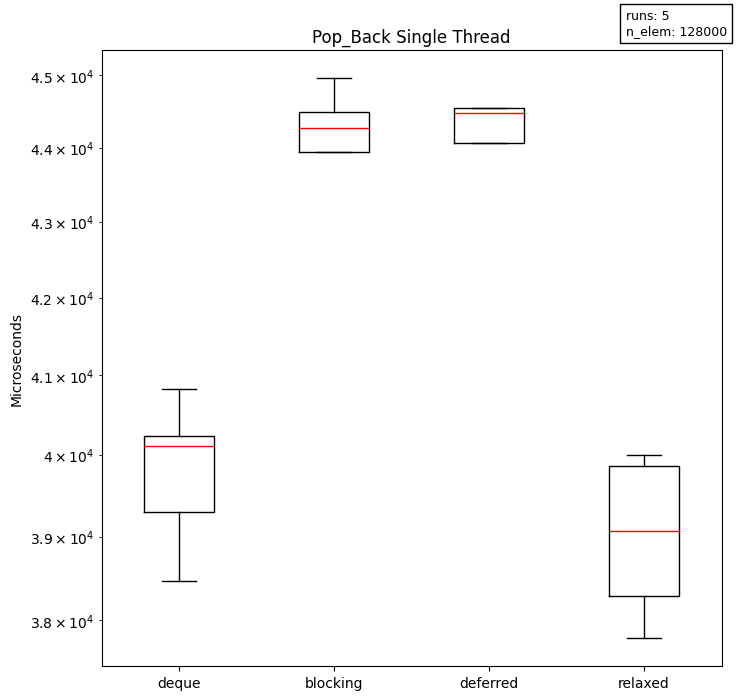


=== Pop_Front Single Thread ===
deque: 39938.0
blocking: 44800.0
deferred: 44686.0
relaxed: 38888.0


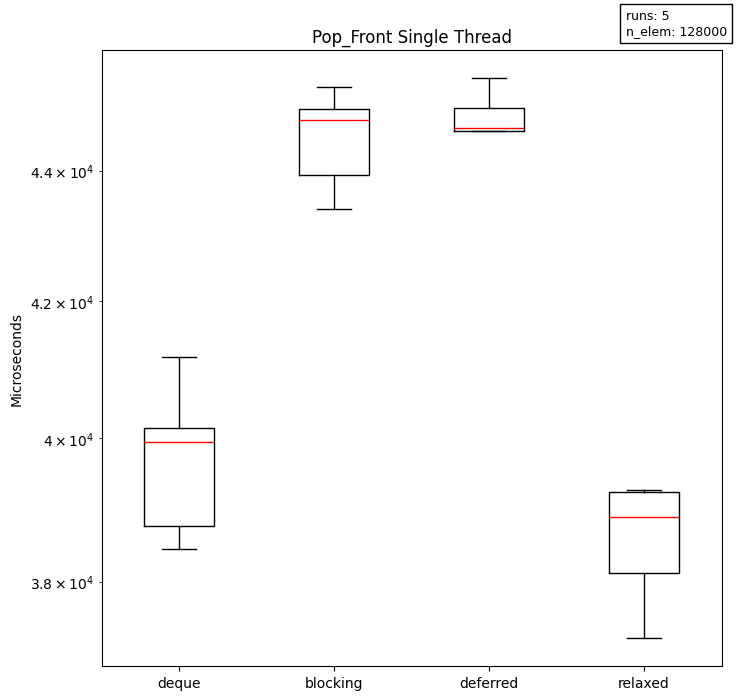


=== Push_Back Single Thread ===
deque: 44327.0
blocking: 34054.0
deferred: 33411.0
relaxed: 28857.0


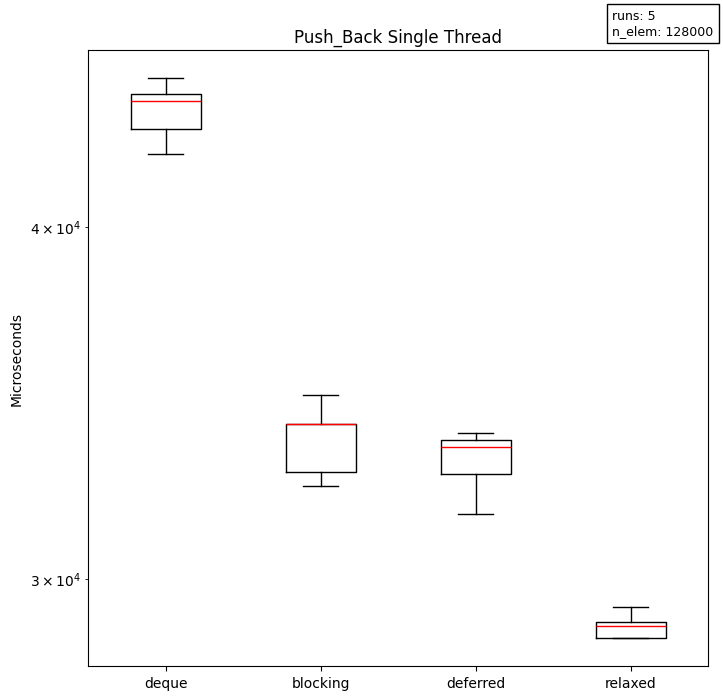


=== Push_Front Single Thread ===
deque: 45195.0
blocking: 33391.0
deferred: 33645.0
relaxed: 28460.0


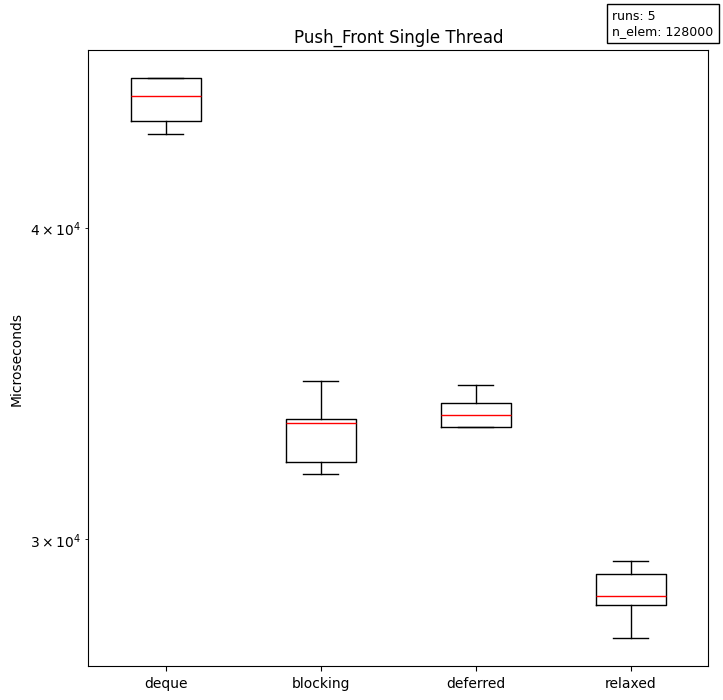

In [34]:
# dati test
nomi = ["deque", "blocking", "deferred", "relaxed"]

# ===================== DATI SINGLE THREAD =====================
# POP_BACK per thread single
dati_pop_back_single = [
    deque_Pop_Back_single,
    blocking_Pop_Back_single,
    deferred_Pop_Back_single,
    relaxed_Pop_Back_single
]

# POP_FRONT per thread single
dati_pop_front_single = [
    deque_Pop_Front_single,
    blocking_Pop_Front_single,
    deferred_Pop_Front_single,
    relaxed_Pop_Front_single
]

# PUSH_BACK per thread single
dati_push_back_single = [
    deque_Push_Back_single,
    blocking_Push_Back_single,
    deferred_Push_Back_single,
    relaxed_Push_Back_single
]

# PUSH_FRONT per thread single
dati_push_front_single = [
    deque_Push_Front_single,
    blocking_Push_Front_single,
    deferred_Push_Front_single,
    relaxed_Push_Front_single
]

n_elem = 128000

# ===================== Calcola e stampa le mediane =====================
print("=== Pop_Back Single Thread ===")
for nome, dati in zip(nomi, dati_pop_back_single):
    mediana = np.median(dati)
    print(f"{nome}: {mediana}")
plot(dati_pop_back_single, "Pop_Back Single Thread", nomi)

print("\n=== Pop_Front Single Thread ===")
for nome, dati in zip(nomi, dati_pop_front_single):
    mediana = np.median(dati)
    print(f"{nome}: {mediana}")
plot(dati_pop_front_single, "Pop_Front Single Thread", nomi)

print("\n=== Push_Back Single Thread ===")
for nome, dati in zip(nomi, dati_push_back_single):
    mediana = np.median(dati)
    print(f"{nome}: {mediana}")
plot(dati_push_back_single, "Push_Back Single Thread", nomi)

print("\n=== Push_Front Single Thread ===")
for nome, dati in zip(nomi, dati_push_front_single):
    mediana = np.median(dati)
    print(f"{nome}: {mediana}")
plot(dati_push_front_single, "Push_Front Single Thread", nomi)


## multithread

In [35]:
n_thread = [1,2,3,4,5,6,7,8] #,4,8,12,16] #,12,16] #hard code in .sh copialo da li
n_elem = 128000 ##hard code quando fai run di fie.sh

In [36]:
def multi_plot(data1, data2, data3, data4, title, labels, n_threads):
    fig, ax = plt.subplots(figsize=[10, 10])

    boxes = []
    colors = []
    group_positions = []  # Per le etichette centrate

    color_map = ["peachpuff", "orange", "yellow", "blue"]

    for i in range(len(n_threads)):
        boxes.extend([data1[i], data2[i], data3[i], data4[i]])
        colors.extend(color_map)
        # Ogni gruppo di 4 box parte alla posizione 4*i+1 → il centro è +1.5
        group_center = 4 * i + 2.5
        group_positions.append(group_center)

    # Crea boxplot
    bplot = ax.boxplot(boxes, showfliers=False, patch_artist=True)

    # Colori per ogni box
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)

    # Etichette centrate per ogni gruppo
    ax.set_xticks(group_positions)
    ax.set_xticklabels([str(n) for n in n_threads])

    # Etichette e titolo
    ax.set_ylabel('Microseconds')
    ax.set_xlabel('n_threads')
    ax.set_title(title, loc='left')
    ax.set_yscale('log')
    
    # Legenda (usiamo solo il primo gruppo per i colori)
    legend_handles = [bplot["boxes"][i] for i in range(4)]
    ax.legend(legend_handles, labels, loc='upper right')

    # Mediane in rosso
    for median in bplot['medians']:
        median.set_color('red')

    plt.figtext(0.78, 0.98, f"runs: {len(data1[0])}\nn_elem: {n_elem}", fontsize=9, 
            bbox=dict(facecolor='white', edgecolor='black'))

    plt.tight_layout()
    plt.show()

    # ======= Calcolo e stampa delle mediane numeriche =======
    print(f"\n=== Median values for {title} ===")
    medians = [np.median(b) for b in boxes]
    
    for i, n in enumerate(n_threads):
        print(f"\nThreads = {n}")
        for j, label in enumerate(labels):
            idx = i * 4 + j
            print(f"  {label:>12}: {medians[idx]:.2f}")


In [37]:
# ===================== DEQUE =====================
dati_deque_Push_Front_multi = [
    deque_Push_Front_multi_1,
    deque_Push_Front_multi_2,
    deque_Push_Front_multi_3,
    deque_Push_Front_multi_4,
    deque_Push_Front_multi_5,
    deque_Push_Front_multi_6,
    deque_Push_Front_multi_7,
    deque_Push_Front_multi_8
]

dati_deque_Push_Back_multi = [
    deque_Push_Back_multi_1,
    deque_Push_Back_multi_2,
    deque_Push_Back_multi_3,
    deque_Push_Back_multi_4,
    deque_Push_Back_multi_5,
    deque_Push_Back_multi_6,
    deque_Push_Back_multi_7,
    deque_Push_Back_multi_8
]

dati_deque_Pop_Front_multi = [
    deque_Pop_Front_multi_1,
    deque_Pop_Front_multi_2,
    deque_Pop_Front_multi_3,
    deque_Pop_Front_multi_4,
    deque_Pop_Front_multi_5,
    deque_Pop_Front_multi_6,
    deque_Pop_Front_multi_7,
    deque_Pop_Front_multi_8
]

dati_deque_Pop_Back_multi = [
    deque_Pop_Back_multi_1,
    deque_Pop_Back_multi_2,
    deque_Pop_Back_multi_3,
    deque_Pop_Back_multi_4,
    deque_Pop_Back_multi_5,
    deque_Pop_Back_multi_6,
    deque_Pop_Back_multi_7,
    deque_Pop_Back_multi_8
]

# ===================== RELAXED =====================
dati_relaxed_Push_Front_multi = [
    relaxed_Push_Front_multi_1,
    relaxed_Push_Front_multi_2,
    relaxed_Push_Front_multi_3,
    relaxed_Push_Front_multi_4,
    relaxed_Push_Front_multi_5,
    relaxed_Push_Front_multi_6,
    relaxed_Push_Front_multi_7,
    relaxed_Push_Front_multi_8
]

dati_relaxed_Push_Back_multi = [
    relaxed_Push_Back_multi_1,
    relaxed_Push_Back_multi_2,
    relaxed_Push_Back_multi_3,
    relaxed_Push_Back_multi_4,
    relaxed_Push_Back_multi_5,
    relaxed_Push_Back_multi_6,
    relaxed_Push_Back_multi_7,
    relaxed_Push_Back_multi_8
]

dati_relaxed_Pop_Front_multi = [
    relaxed_Pop_Front_multi_1,
    relaxed_Pop_Front_multi_2,
    relaxed_Pop_Front_multi_3,
    relaxed_Pop_Front_multi_4,
    relaxed_Pop_Front_multi_5,
    relaxed_Pop_Front_multi_6,
    relaxed_Pop_Front_multi_7,
    relaxed_Pop_Front_multi_8
]

dati_relaxed_Pop_Back_multi = [
    relaxed_Pop_Back_multi_1,
    relaxed_Pop_Back_multi_2,
    relaxed_Pop_Back_multi_3,
    relaxed_Pop_Back_multi_4,
    relaxed_Pop_Back_multi_5,
    relaxed_Pop_Back_multi_6,
    relaxed_Pop_Back_multi_7,
    relaxed_Pop_Back_multi_8
]

# ===================== DEFERRED =====================
dati_deferred_Push_Front_multi = [
    deferred_Push_Front_multi_1,
    deferred_Push_Front_multi_2,
    deferred_Push_Front_multi_3,
    deferred_Push_Front_multi_4,
    deferred_Push_Front_multi_5,
    deferred_Push_Front_multi_6,
    deferred_Push_Front_multi_7,
    deferred_Push_Front_multi_8
]

dati_deferred_Push_Back_multi = [
    deferred_Push_Back_multi_1,
    deferred_Push_Back_multi_2,
    deferred_Push_Back_multi_3,
    deferred_Push_Back_multi_4,
    deferred_Push_Back_multi_5,
    deferred_Push_Back_multi_6,
    deferred_Push_Back_multi_7,
    deferred_Push_Back_multi_8
]

dati_deferred_Pop_Front_multi = [
    deferred_Pop_Front_multi_1,
    deferred_Pop_Front_multi_2,
    deferred_Pop_Front_multi_3,
    deferred_Pop_Front_multi_4,
    deferred_Pop_Front_multi_5,
    deferred_Pop_Front_multi_6,
    deferred_Pop_Front_multi_7,
    deferred_Pop_Front_multi_8
]

dati_deferred_Pop_Back_multi = [
    deferred_Pop_Back_multi_1,
    deferred_Pop_Back_multi_2,
    deferred_Pop_Back_multi_3,
    deferred_Pop_Back_multi_4,
    deferred_Pop_Back_multi_5,
    deferred_Pop_Back_multi_6,
    deferred_Pop_Back_multi_7,
    deferred_Pop_Back_multi_8
]

# ===================== BLOCKING =====================
dati_blocking_Push_Front_multi = [
    blocking_Push_Front_multi_1,
    blocking_Push_Front_multi_2,
    blocking_Push_Front_multi_3,
    blocking_Push_Front_multi_4,
    blocking_Push_Front_multi_5,
    blocking_Push_Front_multi_6,
    blocking_Push_Front_multi_7,
    blocking_Push_Front_multi_8
]

dati_blocking_Push_Back_multi = [
    blocking_Push_Back_multi_1,
    blocking_Push_Back_multi_2,
    blocking_Push_Back_multi_3,
    blocking_Push_Back_multi_4,
    blocking_Push_Back_multi_5,
    blocking_Push_Back_multi_6,
    blocking_Push_Back_multi_7,
    blocking_Push_Back_multi_8
]

dati_blocking_Pop_Front_multi = [
    blocking_Pop_Front_multi_1,
    blocking_Pop_Front_multi_2,
    blocking_Pop_Front_multi_3,
    blocking_Pop_Front_multi_4,
    blocking_Pop_Front_multi_5,
    blocking_Pop_Front_multi_6,
    blocking_Pop_Front_multi_7,
    blocking_Pop_Front_multi_8
]

dati_blocking_Pop_Back_multi = [
    blocking_Pop_Back_multi_1,
    blocking_Pop_Back_multi_2,
    blocking_Pop_Back_multi_3,
    blocking_Pop_Back_multi_4,
    blocking_Pop_Back_multi_5,
    blocking_Pop_Back_multi_6,
    blocking_Pop_Back_multi_7,
    blocking_Pop_Back_multi_8
]


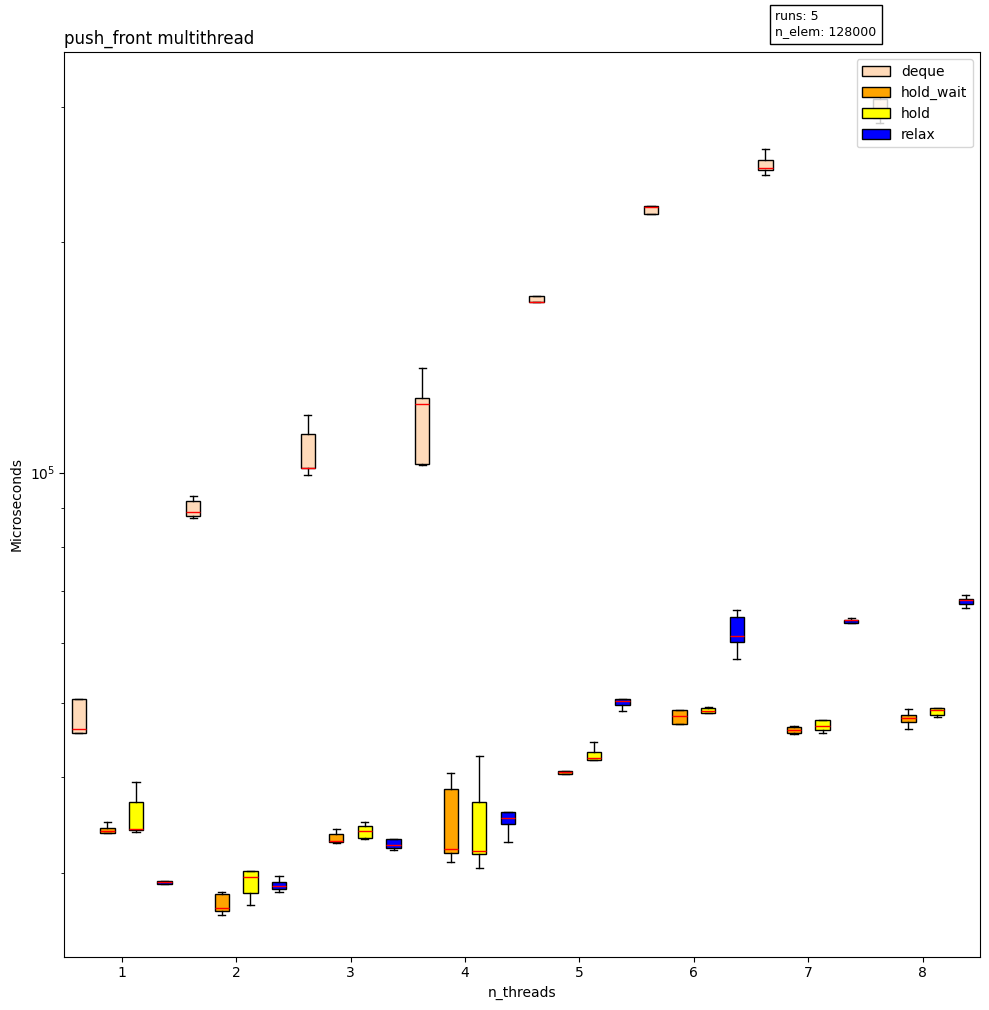


=== Median values for push_front multithread ===

Threads = 1
         deque: 46238.00
     hold_wait: 34094.00
          hold: 34229.00
         relax: 29214.00

Threads = 2
         deque: 88882.00
     hold_wait: 26978.00
          hold: 29688.00
         relax: 28875.00

Threads = 3
         deque: 101550.00
     hold_wait: 33036.00
          hold: 34086.00
         relax: 32648.00

Threads = 4
         deque: 122734.00
     hold_wait: 32284.00
          hold: 32101.00
         relax: 35447.00

Threads = 5
         deque: 167216.00
     hold_wait: 40712.00
          hold: 42370.00
         relax: 50368.00

Threads = 6
         deque: 222365.00
     hold_wait: 48062.00
          hold: 48798.00
         relax: 61230.00

Threads = 7
         deque: 249933.00
     hold_wait: 46100.00
          hold: 46721.00
         relax: 64169.00

Threads = 8
         deque: 292528.00
     hold_wait: 47762.00
          hold: 49046.00
         relax: 68092.00


In [38]:
multi_plot(dati_deque_Push_Front_multi, dati_blocking_Push_Front_multi, dati_deferred_Push_Front_multi,dati_relaxed_Push_Front_multi , "push_front multithread", ["deque","hold_wait","hold","relax"], n_thread)

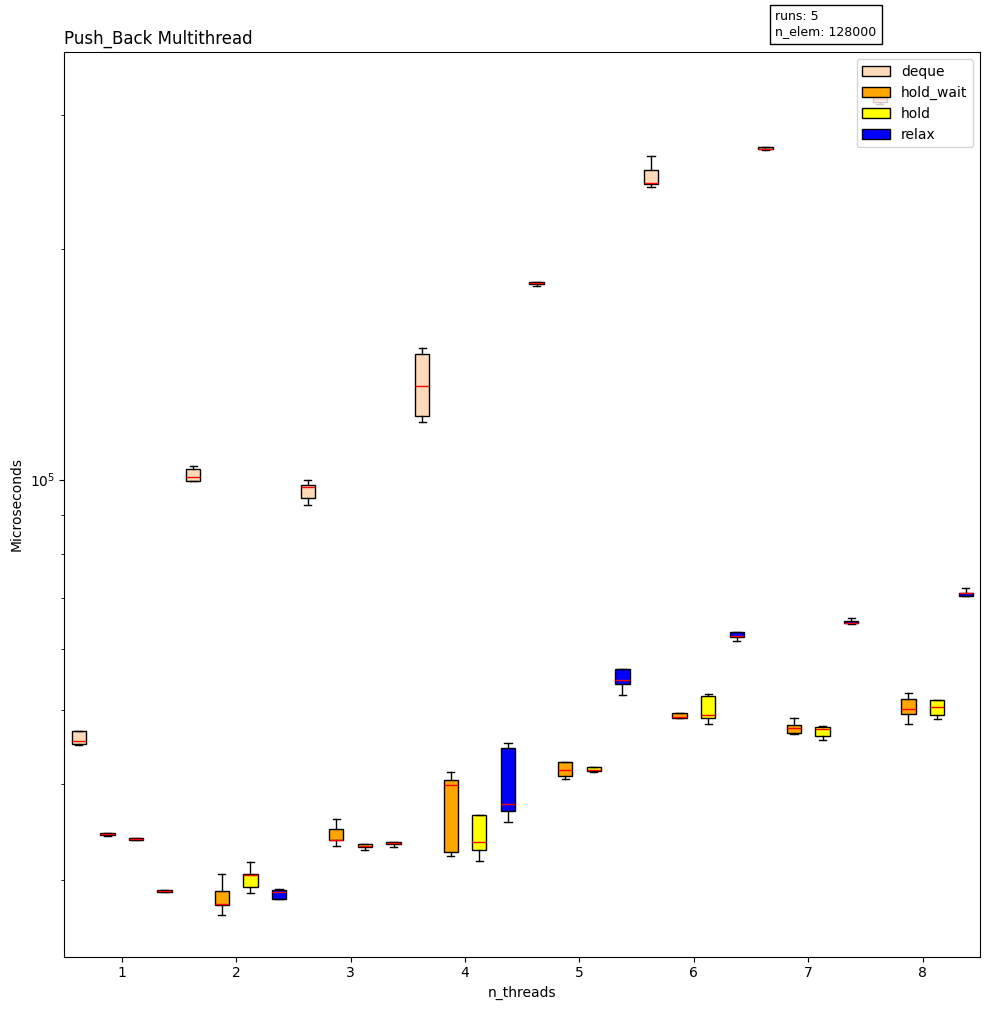


=== Median values for Push_Back Multithread ===

Threads = 1
         deque: 45477.00
     hold_wait: 34395.00
          hold: 33918.00
         relax: 28982.00

Threads = 2
         deque: 100752.00
     hold_wait: 27866.00
          hold: 30438.00
         relax: 28929.00

Threads = 3
         deque: 97750.00
     hold_wait: 33792.00
          hold: 33162.00
         relax: 33470.00

Threads = 4
         deque: 132474.00
     hold_wait: 39907.00
          hold: 33618.00
         relax: 37731.00

Threads = 5
         deque: 180812.00
     hold_wait: 41728.00
          hold: 41786.00
         relax: 54760.00

Threads = 6
         deque: 244411.00
     hold_wait: 48948.00
          hold: 49308.00
         relax: 62511.00

Threads = 7
         deque: 270189.00
     hold_wait: 47389.00
          hold: 47183.00
         relax: 64966.00

Threads = 8
         deque: 314224.00
     hold_wait: 50107.00
          hold: 50461.00
         relax: 71060.00


In [39]:
multi_plot(
    dati_deque_Push_Back_multi,
    dati_blocking_Push_Back_multi,
    dati_deferred_Push_Back_multi,
    dati_relaxed_Push_Back_multi,
    "Push_Back Multithread",
    ["deque","hold_wait","hold","relax"], n_thread
)

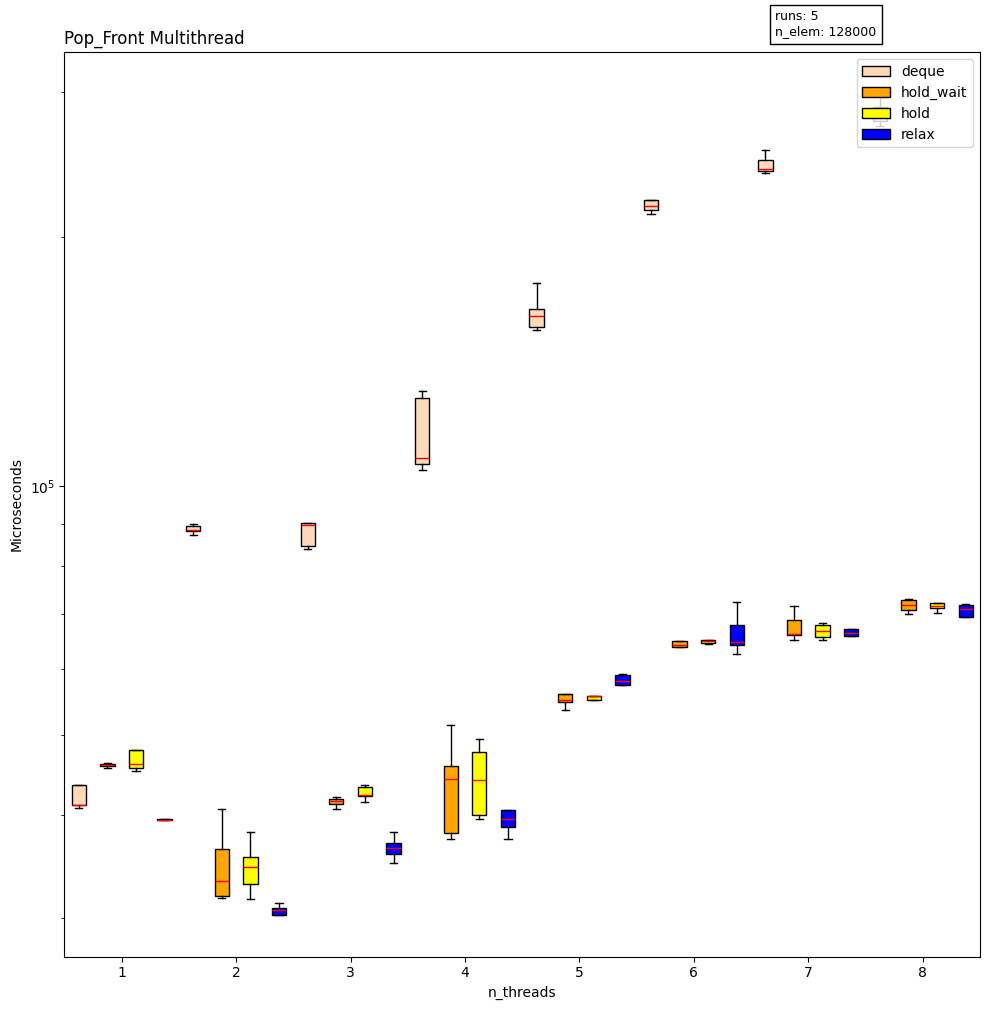


=== Median values for Pop_Front Multithread ===

Threads = 1
         deque: 41075.00
     hold_wait: 45931.00
          hold: 45994.00
         relax: 39438.00

Threads = 2
         deque: 88418.00
     hold_wait: 33258.00
          hold: 34567.00
         relax: 30614.00

Threads = 3
         deque: 89681.00
     hold_wait: 41513.00
          hold: 42198.00
         relax: 36465.00

Threads = 4
         deque: 108248.00
     hold_wait: 44177.00
          hold: 44030.00
         relax: 39505.00

Threads = 5
         deque: 160723.00
     hold_wait: 55053.00
          hold: 55641.00
         relax: 58124.00

Threads = 6
         deque: 218033.00
     hold_wait: 64130.00
          hold: 64876.00
         relax: 64710.00

Threads = 7
         deque: 242281.00
     hold_wait: 66177.00
          hold: 66770.00
         relax: 66442.00

Threads = 8
         deque: 281991.00
     hold_wait: 71797.00
          hold: 71507.00
         relax: 70956.00


In [40]:
multi_plot(
    dati_deque_Pop_Front_multi,
    dati_blocking_Pop_Front_multi,
    dati_deferred_Pop_Front_multi,
    dati_relaxed_Pop_Front_multi,
    "Pop_Front Multithread",
    ["deque","hold_wait","hold","relax"], n_thread
)

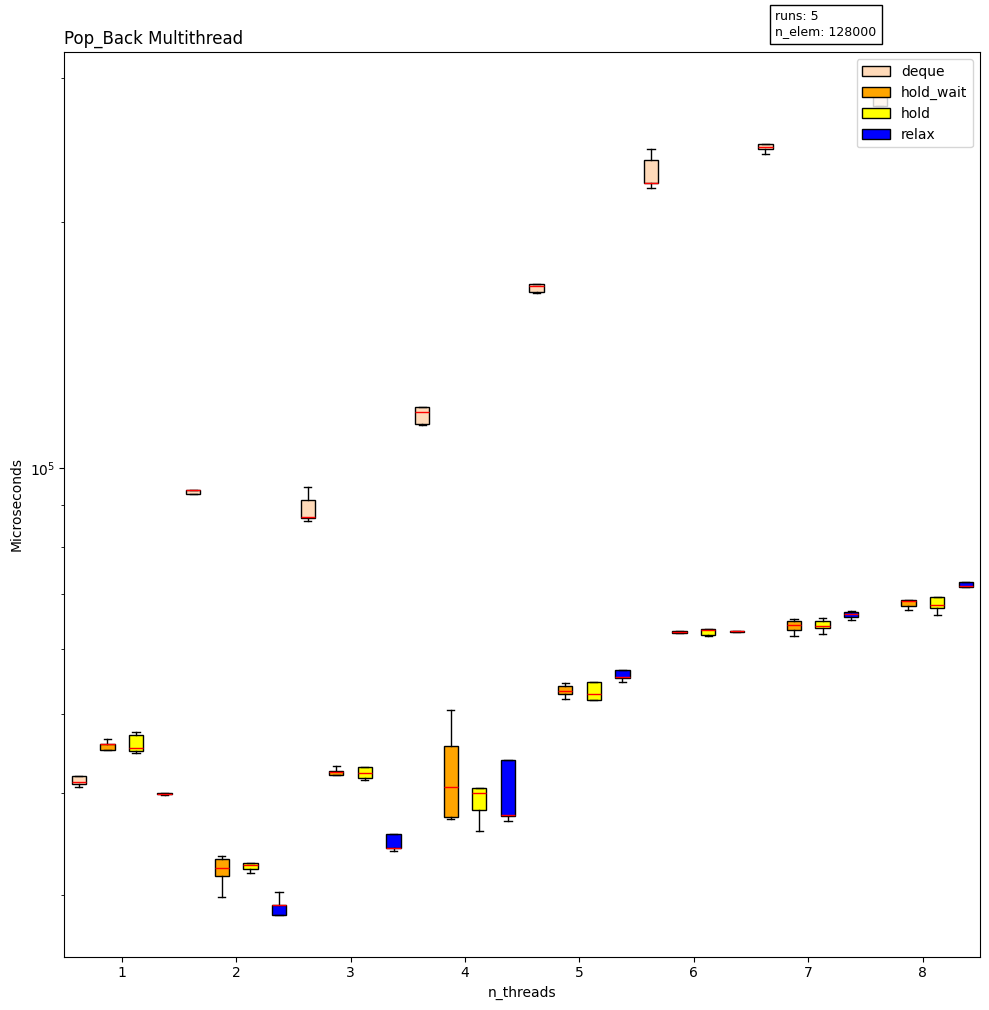


=== Median values for Pop_Back Multithread ===

Threads = 1
         deque: 41300.00
     hold_wait: 45887.00
          hold: 45447.00
         relax: 39916.00

Threads = 2
         deque: 93971.00
     hold_wait: 32336.00
          hold: 32615.00
         relax: 29170.00

Threads = 3
         deque: 86985.00
     hold_wait: 42371.00
          hold: 42348.00
         relax: 34265.00

Threads = 4
         deque: 116961.00
     hold_wait: 40666.00
          hold: 40025.00
         relax: 37626.00

Threads = 5
         deque: 166906.00
     hold_wait: 53255.00
          hold: 52858.00
         relax: 55406.00

Threads = 6
         deque: 223446.00
     hold_wait: 63016.00
          hold: 63371.00
         relax: 63136.00

Threads = 7
         deque: 247235.00
     hold_wait: 64265.00
          hold: 64008.00
         relax: 66213.00

Threads = 8
         deque: 284396.00
     hold_wait: 68670.00
          hold: 67894.00
         relax: 71648.00


In [41]:
multi_plot(
    dati_deque_Pop_Back_multi,
    dati_blocking_Pop_Back_multi,
    dati_deferred_Pop_Back_multi,
    dati_relaxed_Pop_Back_multi,
    "Pop_Back Multithread",
    ["deque","hold_wait","hold","relax"], n_thread
)

## Random

In [42]:
# ===================== DEQUE =====================
dati_deque_random_multi = [
    deque_random_multi_1,
    deque_random_multi_2,
    deque_random_multi_3,
    deque_random_multi_4,
    deque_random_multi_5,
    deque_random_multi_6,
    deque_random_multi_7,
    deque_random_multi_8
]

# ===================== RELAXED =====================
dati_relaxed_random_multi = [
    relaxed_random_multi_1,
    relaxed_random_multi_2,
    relaxed_random_multi_3,
    relaxed_random_multi_4,
    relaxed_random_multi_5,
    relaxed_random_multi_6,
    relaxed_random_multi_7,
    relaxed_random_multi_8
]

# ===================== DEFERRED =====================
dati_deferred_random_multi = [
    deferred_random_multi_1,
    deferred_random_multi_2,
    deferred_random_multi_3,
    deferred_random_multi_4,
    deferred_random_multi_5,
    deferred_random_multi_6,
    deferred_random_multi_7,
    deferred_random_multi_8
]

# ===================== BLOCKING =====================
dati_blocking_random_multi = [
    blocking_random_multi_1,
    blocking_random_multi_2,
    blocking_random_multi_3,
    blocking_random_multi_4,
    blocking_random_multi_5,
    blocking_random_multi_6,
    blocking_random_multi_7,
    blocking_random_multi_8
]


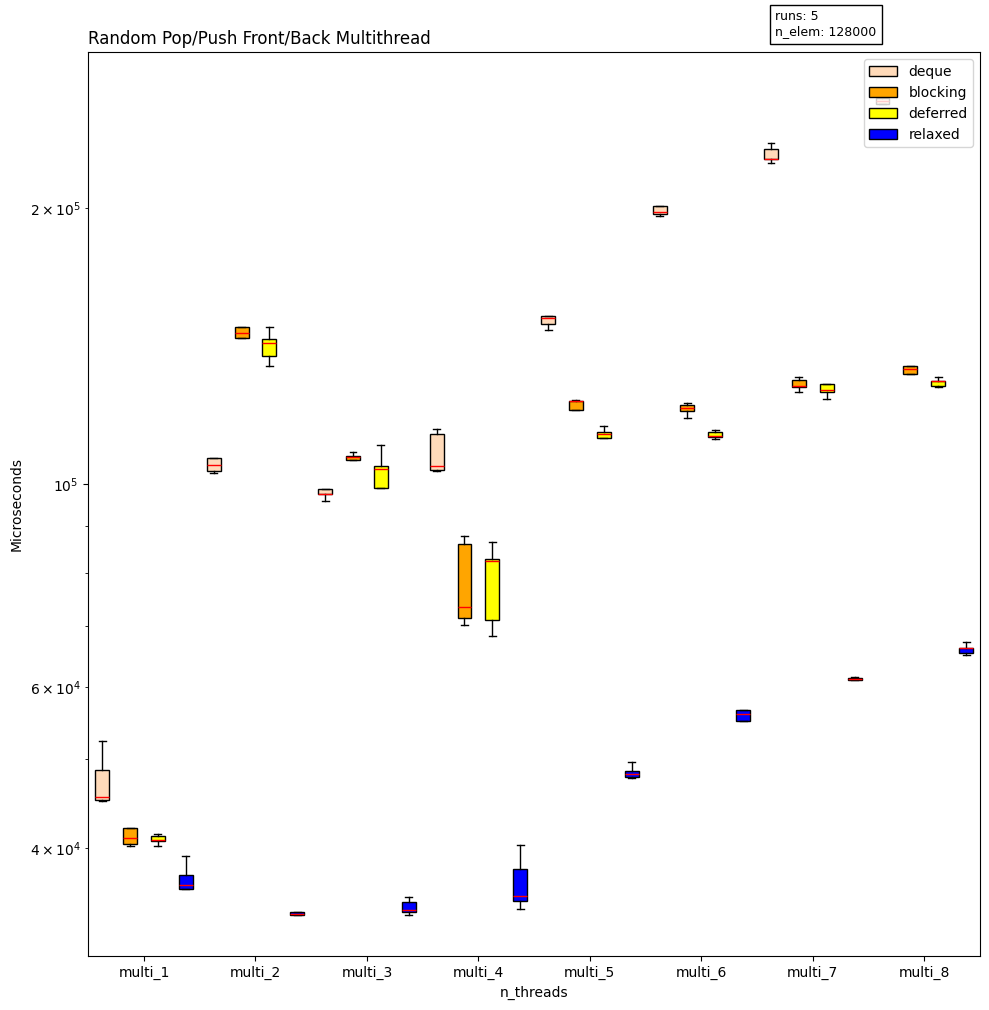


=== Median values for Random Pop/Push Front/Back Multithread ===

Threads = multi_1
         deque: 45433.00
      blocking: 40983.00
      deferred: 40864.00
       relaxed: 36421.00

Threads = multi_2
         deque: 104881.00
      blocking: 146078.00
      deferred: 142464.00
       relaxed: 33852.00

Threads = multi_3
         deque: 97438.00
      blocking: 107015.00
      deferred: 103812.00
       relaxed: 34265.00

Threads = multi_4
         deque: 104548.00
      blocking: 73350.00
      deferred: 82346.00
       relaxed: 35479.00

Threads = multi_5
         deque: 151772.00
      blocking: 123044.00
      deferred: 113433.00
       relaxed: 48248.00

Threads = multi_6
         deque: 198042.00
      blocking: 121063.00
      deferred: 112788.00
       relaxed: 56109.00

Threads = multi_7
         deque: 226388.00
      blocking: 128069.00
      deferred: 126586.00
       relaxed: 61206.00

Threads = multi_8
         deque: 261736.00
      blocking: 133568.00
      deferred:

In [43]:
multi_plot(
    dati_deque_random_multi,
    dati_blocking_random_multi,
    dati_deferred_random_multi,
    dati_relaxed_random_multi,
    "Random Pop/Push Front/Back Multithread",
    ["deque","blocking","deferred","relaxed"],
    ["multi_1", "multi_2", "multi_3", "multi_4","multi_5", "multi_6", "multi_7", "multi_8"]
)
